In [1]:
import os

# Create the folder structure
os.makedirs("DecisionProject/models", exist_ok=True)
print("Folders created successfully!")

Folders created successfully!


In [ ]:
!pip install bayesflow==2.0.12

In [2]:
!find /kaggle/input -type f | grep "trained_rdm"

/kaggle/input/datasets/rehansharief/weights/trained_rdm_400trials.weights.h5


In [3]:
import os

WEIGHTS_PATH = "/kaggle/input/datasets/rehansharief/weights/trained_rdm_400trials.weights.h5"

print(os.path.exists(WEIGHTS_PATH))
print(os.path.getsize(WEIGHTS_PATH) / 1024**2, "MB")

True
8.590255737304688 MB


In [20]:
import os

print("Current working directory:", os.getcwd())

print("\nFiles/folders available:")
for root, dirs, files in os.walk("/kaggle/working"):
    level = root.replace("/kaggle/working", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

Current working directory: /kaggle/working

Files/folders available:
working/
  DecisionProject/
    tests/
    analysis/
      prepare_evans_data.py
      validate_all_participants.py
      evaluate_rdm.py
      posterior_recovery.py
      infer_all_participants.py
    sbi/
      workflow.py
      adapter.py
      simulator.py
      prior.py
      __init__.py
      __pycache__/
        prior.cpython-312.pyc
        simulator.cpython-312.pyc
        adapter.cpython-312.pyc
        __init__.cpython-312.pyc
        workflow.cpython-312.pyc
    training/
      train.py
    models/
      base.py
      rdm.py
      __pycache__/
        rdm.cpython-312.pyc
        base.cpython-312.pyc
  .virtual_documents/
    __notebook_source__.ipynb


In [21]:
print("\nKaggle input:")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:20]:
        print(f"{indent}  {file}")


Kaggle input:
input/
  datasets/
    rehansharief/
      weights/
        trained_rdm_400trials.weights.h5
      evans-double-response-data/
        parsedData_doubleResp.Rdata
      rtdataobjects/
        RTdataobjects.Rdata


In [22]:
import os

for root, dirs, files in os.walk("/kaggle/working/DecisionProject"):
    level = root.replace("/kaggle/working/DecisionProject", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

DecisionProject/
  tests/
  analysis/
    prepare_evans_data.py
    validate_all_participants.py
    evaluate_rdm.py
    posterior_recovery.py
    infer_all_participants.py
  sbi/
    workflow.py
    adapter.py
    simulator.py
    prior.py
    __init__.py
    __pycache__/
      prior.cpython-312.pyc
      simulator.cpython-312.pyc
      adapter.cpython-312.pyc
      __init__.cpython-312.pyc
      workflow.cpython-312.pyc
  training/
    train.py
  models/
    base.py
    rdm.py
    __pycache__/
      rdm.cpython-312.pyc
      base.cpython-312.pyc


In [2]:
import sys

# Make DecisionProject/sbi and DecisionProject/models importable
sys.path.insert(0, "/kaggle/working/DecisionProject")

from sbi.workflow import workflow

print("✅ Workflow imported successfully")

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-08-09 16:27:46,674:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


✅ Workflow imported successfully


In [3]:
WEIGHTS_PATH = "/kaggle/input/datasets/rehansharief/weights/trained_rdm_400trials.weights.h5"

# Build the network using one adapted simulation
dummy = workflow.simulate_adapted((1,))

print("Dummy simulation created.")

# Build the network architecture
workflow.approximator.build_from_data(dummy)

print("Network architecture built.")

# Load your already-trained weights
workflow.approximator.load_weights(WEIGHTS_PATH)

print(" TRAINED WEIGHTS LOADED SUCCESSFULLY")

Dummy simulation created.
Network architecture built.
 TRAINED WEIGHTS LOADED SUCCESSFULLY


In [14]:
import os
import gc
import numpy as np
import pandas as pd

# ============================================================
# FINISH SBC IN SMALL CHUNKS
# ============================================================

N_DATASETS = 300
N_POSTERIOR = 500
CHUNK_SIZE = 20

PARAMETERS = ["A", "b", "vc", "ve", "t0", "sv", "ster"]

PROGRESS_FILE = "/kaggle/working/sbc_progress.csv"

# Load existing progress
progress_df = pd.read_csv(PROGRESS_FILE)

completed = set(progress_df["dataset"].astype(int))

print(f"Already completed: {len(completed)}/{N_DATASETS}")

# Find the next 5 unfinished datasets
remaining = [
    i for i in range(N_DATASETS)
    if i not in completed
]

chunk = remaining[:CHUNK_SIZE]

print(f"Running datasets: {[i + 1 for i in chunk]}")

# ------------------------------------------------------------
# Run only this small chunk
# ------------------------------------------------------------

for i in chunk:

    print(f"\nRunning synthetic dataset {i + 1}/{N_DATASETS}")

    test_data = workflow.simulate_adapted((1,))

    true_params = test_data["inference_variables"][0]

    posterior = workflow.sample(
        num_samples=N_POSTERIOR,
        conditions={
            "summary_variables": test_data["summary_variables"]
        }
    )

    row = {"dataset": i}

    for j, parameter in enumerate(PARAMETERS):

        true_value = float(true_params[j])

        samples = posterior[parameter][0, :, 0]

        rank = int(np.sum(samples < true_value))

        row[f"{parameter}_rank"] = rank

    progress_df = pd.concat(
        [progress_df, pd.DataFrame([row])],
        ignore_index=True
    )

    # SAVE IMMEDIATELY
    progress_df.to_csv(PROGRESS_FILE, index=False)

    print(f"Saved progress: {len(progress_df)}/{N_DATASETS}")

    # Release temporary Python objects
    del test_data, posterior
    gc.collect()

print("\n✅ Chunk finished.")
print(f"Total completed: {len(progress_df)}/{N_DATASETS}")

Already completed: 280/300
Running datasets: [281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300]

Running synthetic dataset 281/300


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.67 seconds.


Saved progress: 281/300

Running synthetic dataset 282/300


...

Saved progress: 299/300

Running synthetic dataset 300/300


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.78 seconds.


Saved progress: 300/300

✅ Chunk finished.
Total completed: 300/300


Total SBC datasets: 300
Unique dataset IDs: 300


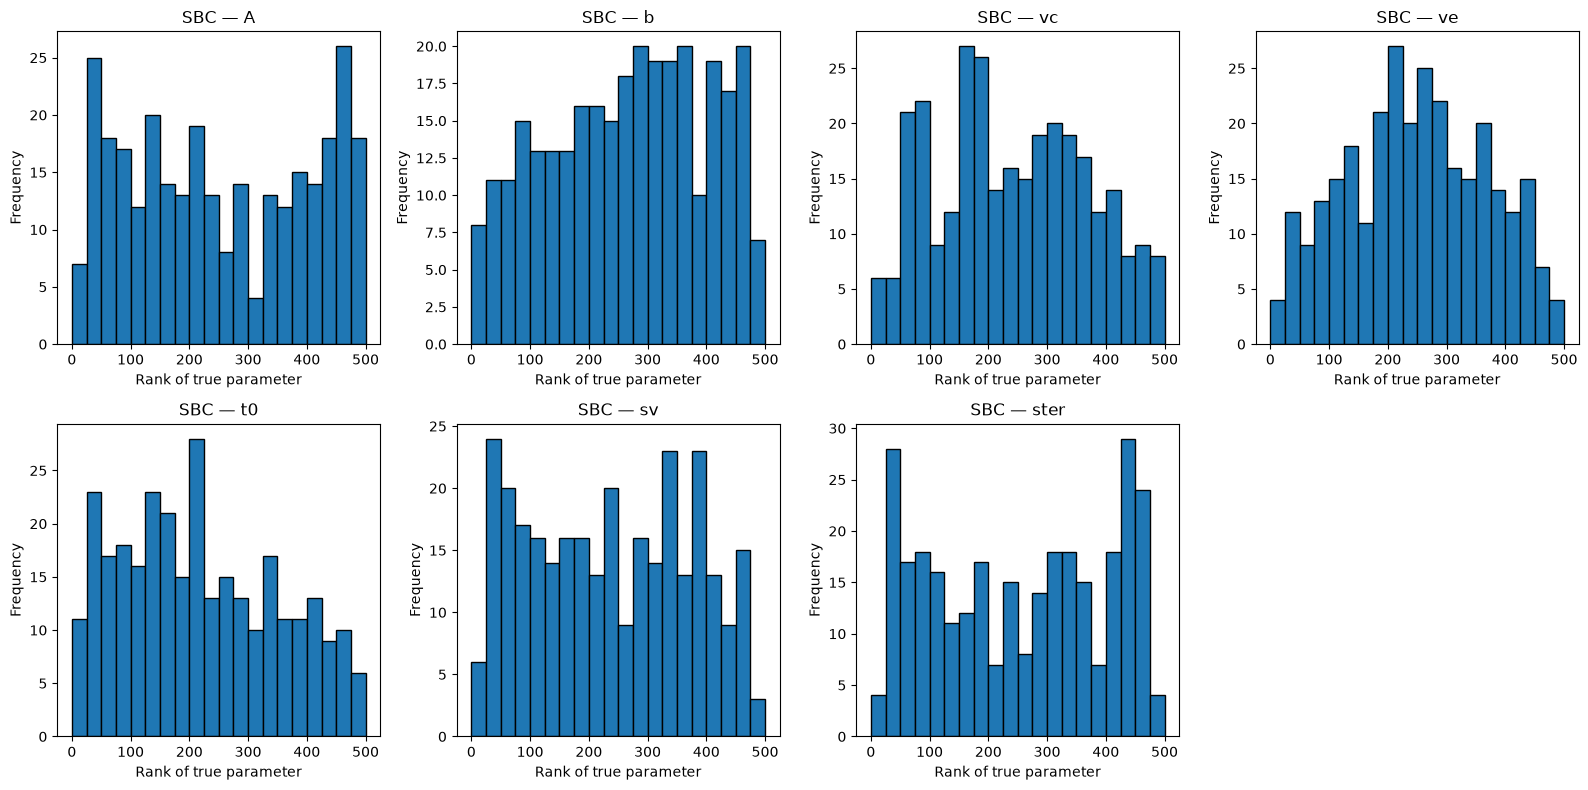


✅ FINAL 200-DATASET SBC PLOT SAVED
/kaggle/working/sbc_rank_histograms_300.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the complete SBC results
sbc_df = pd.read_csv("/kaggle/working/sbc_progress.csv")

PARAMETERS = ["A", "b", "vc", "ve", "t0", "sv", "ster"]
N_POSTERIOR = 500

print(f"Total SBC datasets: {len(sbc_df)}")
print(f"Unique dataset IDs: {sbc_df['dataset'].nunique()}")

# Check that we really have 200 unique simulations
assert len(sbc_df) == 300
assert sbc_df["dataset"].nunique() == 300

# ------------------------------------------------------------
# Final SBC rank histograms
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, parameter in enumerate(PARAMETERS):

    ranks = sbc_df[f"{parameter}_rank"]

    axes[i].hist(
        ranks,
        bins=20,
        range=(0, N_POSTERIOR),
        edgecolor="black"
    )

    axes[i].set_title(f"SBC — {parameter}")
    axes[i].set_xlabel("Rank of true parameter")
    axes[i].set_ylabel("Frequency")

axes[-1].axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/sbc_rank_histograms_300.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ FINAL 200-DATASET SBC PLOT SAVED")
print("/kaggle/working/sbc_rank_histograms_300.png")

In [4]:
%%writefile DecisionProject/models/base.py

"""
base.py

Base classes shared by all evidence accumulation models.

This module defines the common interfaces and data structures used
throughout the project.

Author:
    Rehan Sharief et al.

Project:
    Simulation-Based Inference for Double Responses
"""

from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Optional

import numpy as np


# ============================================================
# Result of ONE simulated trial
# ============================================================

@dataclass(slots=True)
class SimulationResult:
    """
    Stores the outcome of a single decision trial.

    Attributes
    ----------
    response
        Initial response (1 or 2)

    rt
        Initial response time (seconds)

    double_response
        True if a second response occurred.

    double_response_rt
        Time after the first response at which the
        double response occurred.

        None if no double response occurred.
    """

    response: int
    rt: float
    double_response: bool
    double_response_rt: Optional[float]


# ============================================================
# Result of MANY trials
# ============================================================

@dataclass(slots=True)
class BatchSimulation:
    """
    Container for multiple simulated trials.

    All arrays have shape (n_trials,).
    """

    responses: np.ndarray
    rts: np.ndarray
    double_responses: np.ndarray
    double_response_rts: np.ndarray

    def as_dict(self) -> dict:
        """
        Convert results to a dictionary.

        BayesFlow will later consume this dictionary.
        """

        return {

            "response": self.responses,

            "rt": self.rts,

            "double_response": self.double_responses,

            "double_response_rt": self.double_response_rts,

        }


# ============================================================
# Base Decision Model
# ============================================================

class DecisionModel(ABC):
    """
    Abstract base class for all decision models.

    Future models

        RDM
        LCA
        FFIDM

    will inherit from this class.
    """

    def __init__(
        self,
        dt: float = 0.001,
        max_steps: int = 10000,
        dr_steps: int = 2000,
        noise_sd: float = 1.0,
        seed: Optional[int] = None,
    ):

        self.dt = dt

        self.max_steps = max_steps

        self.dr_steps = dr_steps

        self.noise_sd = noise_sd

        self.rng = np.random.default_rng(seed)

    # --------------------------------------------------------

    @abstractmethod
    def simulate_trial(
        self,
        parameters: dict,
    ) -> SimulationResult:
        """
        Simulate one decision trial.
        """
        pass

    # --------------------------------------------------------

    def simulate(
        self,
        parameters: dict,
        n_trials: int,
    ) -> BatchSimulation:
        """
        Simulate multiple independent trials.
        """

        responses = np.empty(n_trials, dtype=np.int32)

        rts = np.empty(n_trials, dtype=np.float64)

        dr = np.empty(n_trials, dtype=bool)

        drrt = np.empty(n_trials, dtype=np.float64)

        drrt.fill(np.nan)

        for i in range(n_trials):

            result = self.simulate_trial(parameters)

            responses[i] = result.response

            rts[i] = result.rt

            dr[i] = result.double_response

            if result.double_response_rt is not None:

                drrt[i] = result.double_response_rt

        return BatchSimulation(

            responses=responses,

            rts=rts,

            double_responses=dr,

            double_response_rts=drrt,

        )

    # --------------------------------------------------------

    @staticmethod
    def validate_positive(name: str, value: float):

        if value <= 0:

            raise ValueError(

                f"{name} must be positive, got {value}"

            )

    # --------------------------------------------------------

    @staticmethod
    def validate_probability(name: str, value: float):

        if not (0.0 <= value <= 1.0):

            raise ValueError(

                f"{name} must lie in [0,1], got {value}"

            )

Overwriting DecisionProject/models/base.py


In [ ]:
import sys
# Tell Python to look inside your new DecisionProject folder
sys.path.append("/kaggle/working/DecisionProject")

# Run the test to import your saved code
from models.base import DecisionModel
from models.base import SimulationResult
from models.base import BatchSimulation

print("Module imported successfully!")

In [5]:
%%writefile DecisionProject/models/rdm.py


from __future__ import annotations

from dataclasses import dataclass
import numpy as np
from enum import Enum

from .base import DecisionModel, SimulationResult


@dataclass(slots=True)
class RDMParameters:
    A: float
    b: float
    vc: float
    ve: float
    t0: float
    sv: float
    ster: float = 0.0


class DoubleResponseMode(Enum):
    """Definition used for detecting a double response."""

    PRIMARY = "primary"
    ALTERNATIVE = "alternative"
# ============================================================
# Trial State
# ============================================================

@dataclass(slots=True)
class TrialState:
    """
    Mutable state of a single RDM trial.

    This object stores the values that evolve over time during
    evidence accumulation.
    """

    evidence: np.ndarray
    drift: np.ndarray
    threshold: float
    elapsed_time: float = 0.0
    
class RDM(DecisionModel):
    """Racing Diffusion Model foundation."""
    def __init__(
        self,
        *args,
        double_response_mode=DoubleResponseMode.PRIMARY,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.double_response_mode = double_response_mode

    @staticmethod
    def from_dict(parameters: dict) -> RDMParameters:
        return RDMParameters(**parameters)

    def _threshold(self, p: RDMParameters) -> float:
        """Decision threshold."""
        return p.A + p.b
    
    
    def _initialize_trial(self, p: RDMParameters) -> TrialState:
        """Initialize a new decision trial."""
        evidence = self.rng.uniform(
        low=0.0,
        high=p.A,
        size=2,)
        
        drift = np.array(
        [
            p.vc + self.rng.normal(0.0, p.sv),
            p.ve + self.rng.normal(0.0, p.sv),
        ],dtype=np.float64,)
        
        return TrialState(
        evidence=evidence,
        drift=drift,
        threshold=self._threshold(p),)
    
    
    def _sample_drift(self, p: RDMParameters) -> np.ndarray:
        return np.array([
            p.vc + self.rng.normal(0.0, p.sv),
            p.ve + self.rng.normal(0.0, p.sv),
        ])

    def simulate_trial(self, parameters) -> SimulationResult:
        if isinstance(parameters, dict):
            params = self.from_dict(parameters)
        else:
            params = parameters

        state = self._initialize_trial(params)
        
        winner, elapsed = self._accumulate_until(state)
        first_rt = elapsed

        if winner is None:
            winner = 0

        double_response, dr_rt = self._run_double_response(
            state,
            winner,
        )
        
        # Sample trial-specific non-decision time
        t0_trial = self.rng.uniform(
            params.t0 - params.ster / 2.0,
            params.t0 + params.ster / 2.0,
        )

        return SimulationResult(
            response=int(winner + 1),
            rt=first_rt - (self.dt / 2.0) + t0_trial,
            double_response=double_response,
            double_response_rt=dr_rt,
        )
        
    def _step(self, state: TrialState):
        """
        Perform one Euler-Maruyama integration step.
        """
        noise = self.rng.normal(
            loc=0.0,
            scale=self.noise_sd * np.sqrt(self.dt),
            size=2,
        )

        state.evidence += (
            state.drift * self.dt
            + noise
        )

        state.elapsed_time += self.dt

    def _winner(self, state: TrialState):
        """
        Returns
        None  -> no decision
        0     -> accumulator 1 won
        1     -> accumulator 2 won
        """
        winners = np.where(
            state.evidence >= state.threshold
        )[0]

        if winners.size == 0:
            return None
        
        return winners[0]  # Returns the index of the first accumulator to hit the threshold  
    def _accumulate_until(self, state: TrialState):
        """
        Run the diffusion process until one accumulator
        crosses threshold.

        Returns
        -------
        winner : int
            0 or 1
        elapsed_time : float
        """
        winner = None

        while (
            winner is None
            and state.elapsed_time < self.max_steps * self.dt
        ):
            self._step(state)
            winner = self._winner(state)

        if winner is None:
            winner = 0

        return winner, state.elapsed_time

    def _run_double_response(
        self,
        state: TrialState,
        winner: int,
    ):
        """
        Continue accumulating evidence after the first response.

        Returns
        -------
        bool
            True if the losing accumulator also reaches threshold.
        float | None
            Time after the first response.
        """
        loser = self._loser_index(winner)
        first_response_time = state.elapsed_time

        while (
            state.elapsed_time - first_response_time
            < self.dr_steps * self.dt
        ):
            self._step(state)

            if self._crossed_threshold(
                state.evidence[loser],
                state.threshold,
            ):
                return (
                    True,
                    state.elapsed_time - first_response_time,
                )

        return False, None
        
    def _winner_index(self, winner: int) -> int:
        """Return the index of the winning accumulator."""
        return winner

    def _loser_index(self, winner: int) -> int:
        """Return the index of the losing accumulator."""
        return 1 - winner
    def _crossed_threshold(
        self,
        value: float,
        threshold: float,
    ) -> bool:
        """Check if an accumulator crossed threshold."""
        return value >= threshold    

Overwriting DecisionProject/models/rdm.py


In [ ]:
from models.rdm import RDM, RDMParameters

model = RDM(seed=42)

params = RDMParameters(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
    ster=0.10,
)

for _ in range(5):
    print(model.simulate_trial(params))

In [ ]:
from models.rdm import RDM
from models.rdm import RDMParameters

model = RDM()

params = RDMParameters(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
)

print(model)
print(params)

In [ ]:
from models.rdm import RDM
from models.rdm import RDMParameters

model = RDM(seed=42)

params = RDMParameters(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
)

result = model.simulate_trial(params)

print(result)

In [6]:
import os

# Create the new tests folder
os.makedirs("DecisionProject/tests", exist_ok=True)
print("Tests folder created successfully!")

Tests folder created successfully!


In [ ]:
from models.rdm import RDM, RDMParameters

model = RDM(seed=42)

params = RDMParameters(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
)

print("=" * 50)
print("Running RDM Validation")
print("=" * 50)

responses = []
rts = []
doubles = []
dr_rts = []

N = 1000

for _ in range(N):
    result = model.simulate_trial(params)

    responses.append(result.response)
    rts.append(result.rt)
    doubles.append(result.double_response)
    dr_rts.append(result.double_response_rt)

print(f"Trials               : {N}")
print(f"Mean RT              : {sum(rts)/N:.3f}")
print(f"Accuracy             : {responses.count(1)/N:.3f}")
print(f"Double Response Rate : {sum(doubles)/N:.3f}")

assert all(r in [1, 2] for r in responses)
assert all(rt > 0 for rt in rts)

for d, rt in zip(doubles, dr_rts):
    if d:
        assert rt is not None
        assert rt > 0
    else:
        assert rt is None

print("\n✅ ALL TESTS PASSED!")

In [7]:
import os

# Create the bayesflow folder
os.makedirs("DecisionProject/sbi", exist_ok=True)

# Write the empty __init__.py file
with open("DecisionProject/sbi/__init__.py", "w") as f:
    pass

print("sbi folder and __init__.py created successfully!")

sbi folder and __init__.py created successfully!


In [8]:
%%writefile DecisionProject/sbi/prior.py
"""
Prior distribution for the Racing Diffusion Model.
Compatible with BayesFlow 2.x.
"""

from __future__ import annotations

import numpy as np


def prior_fn() -> dict:
    """
    Sample one parameter vector from the prior.

    Returns
    -------
    dict
        Dictionary whose keys become inference variables.
    """
    rng = np.random.default_rng()

    return {
        "A": rng.uniform(0.20, 0.60),
        "b": rng.uniform(0.40, 1.20),
        "vc": rng.uniform(0.50, 4.00),
        "ve": rng.uniform(0.50, 4.00),
        "t0": rng.uniform(0.15, 0.45),
        "sv": rng.uniform(0.10, 1.00),
        "ster": rng.uniform(0.0, 0.15),
    }

Overwriting DecisionProject/sbi/prior.py


In [ ]:
from sbi.prior import prior_fn

for _ in range(3):
    print(prior_fn())

In [9]:
%%writefile DecisionProject/sbi/simulator.py
"""
BayesFlow simulator wrapper for the Racing Diffusion Model.
"""

from __future__ import annotations

import numpy as np

from models.rdm import RDM, RDMParameters

# -------------------------------------------------------
# One simulator instance
# -------------------------------------------------------
_model = RDM(seed=42)


# -------------------------------------------------------
# BayesFlow Simulator
# -------------------------------------------------------
def simulator_fn(
    A: float,
    b: float,
    vc: float,
    ve: float,
    t0: float,
    sv: float,
    ster: float,
):
    """
    BayesFlow-compatible simulator.

    Parameters are passed individually by BayesFlow.
    Returns a dictionary whose keys match the
    inference_conditions.
    """
    params = RDMParameters(
        A=A,
        b=b,
        vc=vc,
        ve=ve,
        t0=t0,
        sv=sv,
        ster=ster,
    )

    NUM_TRIALS = 400
    observables = []

    for _ in range(NUM_TRIALS):
        result = _model.simulate_trial(params)

        observables.append([
            result.response,
            result.rt,
            float(result.double_response),
            (
                result.double_response_rt
                if result.double_response_rt is not None
                else -1.0
            ),
        ])

    observables = np.asarray(observables, dtype=np.float32)

    return {
        "observables": observables,
    }

Overwriting DecisionProject/sbi/simulator.py


In [ ]:
from sbi.simulator import simulator_fn

x = simulator_fn(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
    ster=0.10
)

print(x)

In [ ]:
import bayesflow as bf

print(bf)

In [10]:
%%writefile DecisionProject/sbi/adapter.py
"""
BayesFlow adapter.
"""

from __future__ import annotations

import bayesflow as bf


def build_adapter():
    """
    Create the BayesFlow adapter.
    """
    return bf.approximators.ContinuousApproximator.build_adapter(
        inference_variables=[
            "A",
            "b",
            "vc",
            "ve",
            "t0",
            "sv",
            "ster",
        ],
        summary_variables="observables",
    )

Overwriting DecisionProject/sbi/adapter.py


In [ ]:
import inspect
import bayesflow as bf

print(inspect.signature(
    bf.approximators.ContinuousApproximator.build_adapter
))

In [ ]:
from sbi.adapter import build_adapter

adapter = build_adapter()

print(adapter)

In [11]:
%%writefile DecisionProject/sbi/workflow.py
"""
Creates the BayesFlow workflow.
"""

from __future__ import annotations

import bayesflow as bf

from sbi.prior import prior_fn
from sbi.simulator import simulator_fn
from sbi.adapter import build_adapter

# --------------------------------------------------
# Build BayesFlow simulator
# --------------------------------------------------
simulator = bf.make_simulator(
    [prior_fn, simulator_fn]
)

# --------------------------------------------------
# Build adapter
# --------------------------------------------------
adapter = build_adapter()

# --------------------------------------------------
# Build summary network
# --------------------------------------------------
summary_network = bf.networks.DeepSet(
    summary_dim=64,
)

# --------------------------------------------------
# Build inference network
# --------------------------------------------------
inference_network = bf.networks.FlowMatching()

# --------------------------------------------------
# Build workflow
# --------------------------------------------------
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_network,
    inference_network=inference_network,
    inference_variables=[
        "A",
        "b",
        "vc",
        "ve",
        "t0",
        "sv",
        "ster",
    ],
    inference_conditions=[
        "observables",
    ],
)

Overwriting DecisionProject/sbi/workflow.py


In [ ]:
from sbi.workflow import workflow

print(workflow)

In [ ]:
from sbi.workflow import workflow

# Build network once
dummy = workflow.simulate_adapted((1,))
workflow.approximator.build_from_data(dummy)

# Load trained weights
workflow.approximator.load_weights("trained_rdm.weights.h5")

print("✅ Ready for inference!")

In [14]:
import os
os.makedirs("DecisionProject/training", exist_ok=True)
print("✓ training directory ready!")

✓ training directory ready!


In [12]:
%%writefile DecisionProject/training/train.py
"""
BayesFlow training script.
"""

from sbi.workflow import workflow

print("=" * 60)
print("Starting BayesFlow Training")
print("=" * 60)

# Build network
dummy = workflow.simulate_adapted((1,))
workflow.approximator.build_from_data(dummy)

history = workflow.fit_online(
    epochs=50,
    batch_size=8,
    num_batches_per_epoch=20,
)

print()
print("=" * 60)
print("Training Finished Successfully!")
print("=" * 60)

print(history.history)

print()
print("=" * 60)
print("Saving Weights...")
print("=" * 60)

workflow.approximator.save_weights(
    "trained_rdm_400trials.weights.h5"
)

print("✅ Weights saved successfully!")

Overwriting DecisionProject/training/train.py


In [ ]:
%run DecisionProject/training/train.py

In [ ]:
from training.train import *

In [13]:
import os

# Create the new analysis folder
os.makedirs("DecisionProject/analysis", exist_ok=True)
print("✓ analysis directory ready!")

✓ analysis directory ready!


In [15]:
%%writefile DecisionProject/analysis/evaluate_rdm.py
"""
Evaluation script for the Racing Diffusion Model.
"""

from collections import Counter
import numpy as np

from models.rdm import RDM, RDMParameters


# ---------------------------------------------------------
# Model
# ---------------------------------------------------------

model = RDM(seed=42)

params = RDMParameters(
    A=0.3,
    b=0.7,
    vc=2.5,
    ve=1.8,
    t0=0.25,
    sv=0.3,
    ster=0.10,
)

N = 10000


# ---------------------------------------------------------
# Simulation
# ---------------------------------------------------------

responses = []
rts = []
double_flags = []

for _ in range(N):
    result = model.simulate_trial(params)

    responses.append(result.response)
    rts.append(result.rt)
    double_flags.append(result.double_response)


responses = np.asarray(responses)
rts = np.asarray(rts)
double_flags = np.asarray(double_flags)


# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

correct = responses == 1
error = responses == 2

correct_rts = rts[correct]
error_rts = rts[error]

correct_dr = double_flags[correct]
error_dr = double_flags[error]


# ---------------------------------------------------------
# Report
# ---------------------------------------------------------

print("=" * 60)
print("RACING DIFFUSION MODEL EVALUATION")
print("=" * 60)

print("\nSimulation Parameters")
print("-" * 60)
print(f"A      : {params.A}")
print(f"b      : {params.b}")
print(f"vc     : {params.vc}")
print(f"ve     : {params.ve}")
print(f"t0     : {params.t0}")
print(f"sv     : {params.sv}")
print(f"ster   : {params.ster}")

print("\nTrials")
print("-" * 60)
print(N)

print("\nOverall RT")
print("-" * 60)
print(f"Mean RT      : {rts.mean():.4f}")
print(f"Median RT    : {np.median(rts):.4f}")
print(f"Std RT       : {rts.std():.4f}")

print("\nCorrect Trials")
print("-" * 60)
print(f"Accuracy     : {correct.mean():.4f}")
print(f"Mean RT      : {correct_rts.mean():.4f}")
print(f"Median RT    : {np.median(correct_rts):.4f}")
print(f"Std RT       : {correct_rts.std():.4f}")

print("\nError Trials")
print("-" * 60)
print(f"Error Rate   : {error.mean():.4f}")
print(f"Mean RT      : {error_rts.mean():.4f}")
print(f"Median RT    : {np.median(error_rts):.4f}")
print(f"Std RT       : {error_rts.std():.4f}")

print("\nDouble Responses")
print("-" * 60)
print(f"Overall      : {double_flags.mean():.4f}")
print(f"Correct      : {correct_dr.mean():.4f}")
print(f"Error        : {error_dr.mean():.4f}")

print("\nResponse Counts")
print("-" * 60)
print(Counter(responses))

print("\nRT Quantiles")
print("-" * 60)

for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"{int(q*100):>2}% : {np.quantile(rts, q):.4f}")

print("=" * 60)

Overwriting DecisionProject/analysis/evaluate_rdm.py


In [ ]:
%run DecisionProject/analysis/evaluate_rdm.py

In [16]:
%%writefile DecisionProject/analysis/posterior_recovery.py

"""
Posterior Recovery for the Racing Diffusion Model.
"""

import numpy as np

from sbi.workflow import workflow

# --------------------------------------------------
# Generate one synthetic dataset
# --------------------------------------------------

batch = workflow.simulate_adapted((1,))

truth = batch["inference_variables"]

# --------------------------------------------------
# Sample posterior
# --------------------------------------------------

samples = workflow.sample(
    num_samples=1000,
    conditions={
        "summary_variables": batch["summary_variables"],
    },
)

parameter_names = [
    "A",
    "b",
    "vc",
    "ve",
    "t0",
    "sv",
    "ster",
]

print("=" * 70)
print("POSTERIOR RECOVERY")
print("=" * 70)

for i, name in enumerate(parameter_names):

    true_value = truth[0, i]

    posterior = samples[name][0, :, 0]

    mean = posterior.mean()
    std = posterior.std()

    print(f"{name:5}")
    print(f"   True : {true_value:.4f}")
    print(f"   Mean : {mean:.4f}")
    print(f"   Std  : {std:.4f}")
    print(f"   Error: {abs(mean - true_value):.4f}")
    print()

Overwriting DecisionProject/analysis/posterior_recovery.py


In [ ]:
%run DecisionProject/analysis/posterior_recovery.py

In [17]:
%%writefile DecisionProject/analysis/prepare_evans_data.py
"""
Prepare one Evans participant for BayesFlow.
"""

import numpy as np
import pyreadr


def load_participant(path, participant):
    """Loads one participant from Evans Experiment 1."""
    result = pyreadr.read_r(path)

    g1 = result["g1"]

    df = g1[g1["ss"] == participant].copy()

    observables = np.column_stack([
        df["resp1"].to_numpy(np.float32),
        (df["rt1"] / 1000.0).to_numpy(np.float32),  # ms -> seconds
        (df["dubbel"] == "dubbel").astype(np.float32),
        (df["rt2"] / 1000.0).to_numpy(np.float32),  # ms -> seconds
    ])

    return observables

Overwriting DecisionProject/analysis/prepare_evans_data.py


In [18]:
%%writefile DecisionProject/analysis/infer_all_participants.py

"""
Infer RDM parameters for all Evans participants.
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from analysis.prepare_evans_data import load_participant
from sbi.workflow import workflow

# --------------------------------------------------
# Load trained network
# --------------------------------------------------

dummy = workflow.simulate_adapted((1,))
workflow.approximator.build_from_data(dummy)

workflow.approximator.load_weights(
    "trained_rdm_400trials.weights.h5"
)

print("Weights loaded!")

# --------------------------------------------------
# Evans dataset
# --------------------------------------------------

path = "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"

participants = [f"m{i}" for i in range(1, 26)]

results = []

# --------------------------------------------------
# Infer one participant at a time
# --------------------------------------------------

for participant in participants:

    print(f"Running {participant}...")

    obs = load_participant(path, participant)

    obs = obs[np.newaxis, ...]

    posterior = workflow.sample(
        num_samples=2000,
        conditions={
            "summary_variables": obs,
        },
    )

    row = {
        "participant": participant,
    }

    for name, samples in posterior.items():
        row[name] = samples.squeeze().mean()

    results.append(row)

# --------------------------------------------------
# Save
# --------------------------------------------------

df = pd.DataFrame(results)

print()
print(df)

df.to_csv(
    "participant_parameters.csv",
    index=False,
)

print()
print("Saved participant_parameters.csv")

Overwriting DecisionProject/analysis/infer_all_participants.py


In [ ]:
%run DecisionProject/analysis/infer_all_participants.py

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("participant_parameters.csv")

# Keep participant names as the index
heatmap_data = df.set_index("participant")

plt.figure(figsize=(10, 8))

plt.imshow(heatmap_data.values, aspect="auto")

plt.colorbar(label="Parameter Value")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Recovered RDM Parameters Across Participants")

plt.tight_layout()

plt.savefig(
    "parameter_heatmap.png",
    dpi=300
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("participant_parameters.csv")

parameters = [
    "A",
    "b",
    "vc",
    "ve",
    "t0",
    "sv",
    "ster",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

axes = axes.flatten()

for i, p in enumerate(parameters):

    axes[i].bar(
        df["participant"],
        df[p]
    )

    axes[i].set_title(p)
    axes[i].tick_params(axis="x", rotation=90)

# Remove unused axes
for j in range(len(parameters), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "parameter_barplots.png",
    dpi=300
)

plt.show()

In [ ]:
import os
import shutil

os.makedirs("results/tables", exist_ok=True)

shutil.copy(
    "parameter_barplots.png",
    "/kaggle/working/results/figures/parameter_barplots.png",
)

print("Done!")

In [ ]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

In [19]:
%%writefile DecisionProject/analysis/validate_all_participants.py

"""
Posterior predictive validation for all Evans participants.
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from analysis.prepare_evans_data import load_participant
from models.rdm import RDM, RDMParameters

# --------------------------------------------------
# Load parameter estimates
# --------------------------------------------------

df = pd.read_csv("participant_parameters.csv")

path = "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"

model = RDM(seed=42)

results = []

for _, row in df.iterrows():

    participant = row["participant"]

    print(f"Validating {participant}")

    # ----------------------------
    # Real participant
    # ----------------------------

    obs = load_participant(path, participant)

    real_resp = obs[:,0]
    real_rt = obs[:,1]
    real_double = obs[:,2]

    # ----------------------------
    # Estimated parameters
    # ----------------------------

    params = RDMParameters(

        A=row["A"],
        b=row["b"],
        vc=row["vc"],
        ve=row["ve"],
        t0=row["t0"],
        sv=row["sv"],
        ster=row["ster"],

    )

    # ----------------------------
    # Simulate 400 trials
    # ----------------------------

    sims = [
        model.simulate_trial(params)
        for _ in range(400)
    ]

    sim_rt = np.array([s.rt for s in sims])

    sim_resp = np.array([s.response for s in sims])

    sim_double = np.array(
        [s.double_response for s in sims]
    )

    # ----------------------------
    # Summary statistics
    # ----------------------------

    real_accuracy = np.mean(real_resp == 1)
    sim_accuracy = np.mean(sim_resp == 1)

    results.append({

        "participant": participant,

        "real_mean_rt": real_rt.mean(),
        "sim_mean_rt": sim_rt.mean(),
        "rt_error":
            abs(real_rt.mean()-sim_rt.mean()),

        "real_accuracy": real_accuracy,
        "sim_accuracy": sim_accuracy,
        "accuracy_error":
            abs(real_accuracy-sim_accuracy),

        "real_double": real_double.mean(),
        "sim_double": sim_double.mean(),
        "double_error":
            abs(real_double.mean()-sim_double.mean()),

    })

# --------------------------------------------------
# Save
# --------------------------------------------------

validation = pd.DataFrame(results)

validation.to_csv(
    "validation_results.csv",
    index=False,
)

print()
print(validation)

print()
print("Saved validation_results.csv")

Overwriting DecisionProject/analysis/validate_all_participants.py


In [ ]:
%run DecisionProject/analysis/validate_all_participants.py

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create folders
os.makedirs("results/figures", exist_ok=True)

# Load data
df = pd.read_csv("participant_parameters.csv")
heat = df.set_index("participant")

plt.figure(figsize=(12, 8))

im = plt.imshow(
    heat.values,
    aspect="auto",
    interpolation="nearest"
)

# Add parameter names
plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    fontsize=11,
    fontweight="bold"
)

# Add participant names
plt.yticks(
    range(len(heat.index)),
    heat.index,
    fontsize=10
)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Recovered Parameter Value", fontsize=11)

# Title
plt.title(
    "Recovered Racing Diffusion Model Parameters\nAcross All 25 Evans Participants",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Write values inside each cell
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        plt.text(
            j,
            i,
            f"{heat.values[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white"
        )

plt.tight_layout()

plt.savefig(
    "results/figures/Figure1_ParameterHeatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("results/figures", exist_ok=True)

df = pd.read_csv("validation_results.csv")

participants = df["participant"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# -------------------------------
# Mean RT
# -------------------------------
axes[0].plot(
    participants,
    df["real_mean_rt"],
    marker="o",
    linewidth=2,
    label="Real"
)

axes[0].plot(
    participants,
    df["sim_mean_rt"],
    marker="s",
    linewidth=2,
    label="RDM"
)

axes[0].set_title("Mean Reaction Time")
axes[0].set_ylabel("Seconds")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -------------------------------
# Accuracy
# -------------------------------
axes[1].plot(
    participants,
    df["real_accuracy"],
    marker="o",
    linewidth=2,
    label="Real"
)

axes[1].plot(
    participants,
    df["sim_accuracy"],
    marker="s",
    linewidth=2,
    label="RDM"
)

axes[1].set_title("Accuracy")
axes[1].set_ylabel("Proportion")
axes[1].legend()
axes[1].grid(alpha=0.3)

# -------------------------------
# Double Responses
# -------------------------------
axes[2].plot(
    participants,
    df["real_double"],
    marker="o",
    linewidth=2,
    label="Real"
)

axes[2].plot(
    participants,
    df["sim_double"],
    marker="s",
    linewidth=2,
    label="RDM"
)

axes[2].set_title("Double Response Rate")
axes[2].set_ylabel("Proportion")
axes[2].set_xlabel("Participant")
axes[2].legend()
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=90)

plt.suptitle(
    "Posterior Predictive Validation Across All Participants",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "results/figures/Figure2_ModelValidation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("results/figures", exist_ok=True)

parameter_names = [
    "A",
    "b",
    "vc",
    "ve",
    "t0",
    "sv",
    "ster",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, name in enumerate(parameter_names):

    s = posterior[name].squeeze()

    axes[i].hist(
        s,
        bins=30,
        density=True
    )

    axes[i].axvline(
        np.mean(s),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {np.mean(s):.3f}"
    )

    axes[i].set_title(name)
    axes[i].legend(fontsize=8)

# Remove unused subplots
for j in range(len(parameter_names), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Posterior Distributions for Participant m11",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "results/figures/Figure3_Posterior_m11.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load validation results
df = pd.read_csv("validation_results.csv")

# Compute summary statistics
summary = pd.DataFrame({
    "Metric": [
        "Mean RT Error (s)",
        "Mean Accuracy Error",
        "Mean Double Response Error"
    ],
    "Average": [
        round(df["rt_error"].mean(), 3),
        round(df["accuracy_error"].mean(), 3),
        round(df["double_error"].mean(), 3),
    ]
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc="center",
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2.0)

for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(1.2)

    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#1F4E78")
    else:
        cell.set_facecolor("#F7F7F7")

plt.title(
    "Table 3. Overall Validation Summary",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.savefig(
    "results/figures/Table3_ValidationSummary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create folder
# --------------------------------------------------

os.makedirs("results/figures", exist_ok=True)

# --------------------------------------------------
# Helper function
# --------------------------------------------------

def save_table_png(df, title, filename):

    rows = len(df)

    fig_height = max(4, rows * 0.35)

    fig, ax = plt.subplots(figsize=(14, fig_height))

    ax.axis("off")

    table = ax.table(
        cellText=df.round(3).values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.1, 1.5)

    # Header style
    for (r, c), cell in table.get_celld().items():

        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)

        if r == 0:
            cell.set_facecolor("#1F4E78")
            cell.set_text_props(
                color="white",
                weight="bold",
            )
        else:
            cell.set_facecolor("#F8F8F8")

    plt.title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.close()


# --------------------------------------------------
# TABLE 1
# --------------------------------------------------

parameters = pd.read_csv("participant_parameters.csv")

save_table_png(
    parameters,
    "Table 1. Recovered RDM Parameters for All Participants",
    "results/figures/Table1_RecoveredParameters.png",
)

# --------------------------------------------------
# TABLE 2
# --------------------------------------------------

validation = pd.read_csv("validation_results.csv")

save_table_png(
    validation,
    "Table 2. Posterior Predictive Validation Across Participants",
    "results/figures/Table2_ModelValidation.png",
)

print("✅ Table 1 saved")
print("✅ Table 2 saved")

In [ ]:
!pip install pyreadr

In [ ]:
import pyreadr

path = "/kaggle/input/datasets/rehansharief/evans-double-response-data/parsedData_doubleResp.Rdata"

result = pyreadr.read_r(path)

print(result.keys())

In [ ]:
for key in result.keys():
    print("=" * 80)
    print(key)
    print(type(result[key]))
    print()

    if hasattr(result[key], "shape"):
        print("Shape:", result[key].shape)

    print(result[key].head())
    print()

In [ ]:
import os

path = "/kaggle/input/datasets/rehansharief/evans-double-response-data"

for root, dirs, files in os.walk(path):
    for f in files:
        print(f)


import pyreadr

result = pyreadr.read_r(path + "/parsedData_doubleResp.Rdata")

print(result)

In [ ]:
import pyreadr

path = "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"

result_rt = pyreadr.read_r(path)

print(result_rt.keys())

In [ ]:
import pyreadr

result = pyreadr.read_r(
    "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"
)

g1 = result["g1"]

In [ ]:
m11 = g1[g1["ss"] == "m11"]

print(m11.shape)

print(m11.head())

In [ ]:
print("Responses")
print(m11["resp1"].value_counts())

print()

print("Correct")
print(m11["gf"].value_counts())

print()

print("Double")
print(m11["dubbel"].value_counts())

In [ ]:
print("Response values")
print(m11["resp1"].unique())

print()

print("Double values")
print(m11["dubbel"].unique())

print()

print("Second response")
print(m11["rep2"].unique())



In [ ]:
print(m11[m11["dubbel"] == "dubbel"][
    ["resp1", "rep2", "rt1", "rt2"]
].head(20))

In [ ]:
import sys
sys.path.append("/kaggle/working/DecisionProject")

from analysis.prepare_evans_data import load_participant

path = "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"

obs = load_participant(path, "m11")

print(obs.shape)

print(obs[:10])

In [ ]:
import importlib

import sbi.simulator
import sbi.workflow

importlib.reload(sbi.simulator)
importlib.reload(sbi.workflow)

from sbi.workflow import workflow

In [ ]:
from sbi.workflow import workflow

dummy = workflow.simulate_adapted((1,))

print(dummy.keys())

print(dummy["summary_variables"].shape)
print(dummy["summary_variables"])

In [ ]:
from analysis.prepare_evans_data import load_participant

path = "/kaggle/input/datasets/rehansharief/rtdataobjects/RTdataobjects.Rdata"

obs = load_participant(path, "m11")

print(obs.shape)

In [ ]:
import numpy as np

obs_batch = obs[np.newaxis, ...]

print(obs_batch.shape)

In [ ]:
print([m for m in dir(workflow) if "sample" in m.lower()])
print([m for m in dir(workflow.approximator) if "sample" in m.lower()])

In [ ]:
obs_batch = obs[np.newaxis, ...]

print(obs_batch.shape)

In [ ]:
posterior = workflow.sample(
    num_samples=2000,
    conditions={
        "summary_variables": obs_batch
    },
)

In [ ]:
print(type(posterior))
print(posterior.keys())

for k, v in posterior.items():
    print(k, v.shape)

In [ ]:
posterior = workflow.sample(
    num_samples=2000,
    conditions={
        "summary_variables": obs_batch
    },
)

In [ ]:
import numpy as np

print("=" * 60)
print("POSTERIOR SUMMARY - Participant m11")
print("=" * 60)

for name, samples in posterior.items():

    s = samples.squeeze()

    print(f"{name:5}")
    print(f"Mean : {np.mean(s):.4f}")
    print(f"Std  : {np.std(s):.4f}")
    print(f"2.5% : {np.percentile(s,2.5):.4f}")
    print(f"50%  : {np.percentile(s,50):.4f}")
    print(f"97.5%: {np.percentile(s,97.5):.4f}")
    print()

In [ ]:
from models.rdm import RDMParameters

estimated_params = RDMParameters(
    A=0.3980,
    b=0.9760,
    vc=0.9820,
    ve=3.7962,
    t0=0.3609,
    sv=0.4832,
    ster=0.0760,
)

print(estimated_params)

In [ ]:
from models.rdm import RDM

import numpy as np

model = RDM(seed=123)

results = [
    model.simulate_trial(estimated_params)
    for _ in range(400)
]

In [ ]:
import numpy as np

rts = np.array([r.rt for r in results])

responses = np.array([r.response for r in results])

double = np.array([r.double_response for r in results])

print("="*60)
print("SIMULATED PARTICIPANT")
print("="*60)

print("Mean RT :", rts.mean())
print("Median RT:", np.median(rts))

print("Response 1:", np.sum(responses==1))
print("Response 2:", np.sum(responses==2))

print("Double Response Rate:",
      double.mean())

In [ ]:
real_rt = obs[:,1]

real_double = obs[:,2]

real_resp = obs[:,0]

print("="*60)
print("REAL PARTICIPANT")
print("="*60)

print("Mean RT :", real_rt.mean())
print("Median RT:", np.median(real_rt))

print("Response 1:", np.sum(real_resp==1))
print("Response 2:", np.sum(real_resp==2))

print("Double Response Rate:",
      real_double.mean())

In [ ]:
from models.rdm import RDM, RDMParameters
import numpy as np

params = RDMParameters(
    A=0.3980,
    b=0.9760,
    vc=0.9820,
    ve=3.7962,
    t0=0.3609,
    sv=0.4832,
    ster=0.0760,
)

model = RDM(seed=42)

results = [model.simulate_trial(params) for _ in range(10000)]

double_rate = np.mean([r.double_response for r in results])
mean_rt = np.mean([r.rt for r in results])

print("Double rate:", double_rate)
print("Mean RT:", mean_rt)